# SEA 820 NLP Final Project  
## Detecting AI-Generated Text

**Team Members:** Atem Ako Eyong Atem and Nahaeli Brunder  
**Student IDs:** 113714224 and 145268223
**Course:** SEA 820 Natural Language Processing  
**Dataset:** `ai_human_sample_40000.csv`  
**Labels:** `0 = Human-written`, `1 = AI-generated`

## Project Goal

The goal of this project is to build, evaluate, and compare two approaches for detecting AI-generated text:

1. A classic **TF-IDF + Logistic Regression** baseline.
2. A fine-tuned **DistilBERT** Transformer classifier.

The evaluation includes accuracy, precision, recall, F1-score, confusion matrices, model comparison, detailed false-positive and false-negative analysis, feature interpretation, and ethical considerations tied to the observed results.

## 1. Environment Setup and Reproducibility

In [2]:
# Run this once in a fresh Google Colab environment:
# !pip install -q transformers datasets accelerate torch scikit-learn pandas matplotlib joblib

import os
import gc
import json
import random
import inspect
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from datasets import Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
    set_seed
)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2. Load and Validate the Dataset

In [3]:
possible_paths = [
    Path("ai_human_sample_40000.csv"),
    Path("/content/ai_human_sample_40000.csv"),
    Path("/mnt/data/ai_human_sample_40000.csv")
]

DATA_PATH = next((p for p in possible_paths if p.exists()), None)

if DATA_PATH is None:
    raise FileNotFoundError(
        "ai_human_sample_40000.csv was not found. "
        "Upload it to Colab or place it beside this notebook."
    )

df = pd.read_csv(DATA_PATH)

required_columns = {"text", "label"}
if not required_columns.issubset(df.columns):
    raise ValueError(
        f"Expected columns {required_columns}, found {df.columns.tolist()}"
    )

df = df[["text", "label"]].copy()
df["text"] = df["text"].astype(str)
df["label"] = df["label"].astype(int)

print("Dataset path:", DATA_PATH)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
display(df.head())

Dataset path: ai_human_sample_40000.csv
Shape: (40000, 2)
Columns: ['text', 'label']


,text,label
0,I agree that having a positive attitude is cr...,1
1,"Throughout my life, I have wondered what it wo...",0
2,"""Unmasking the Face on Mars,"" a fascinating ar...",1
3,Living in a community were less and fewer peop...,0
4,"Dear [State Senator],\n\nThe United States pre...",1


## 3. Data Quality and Exploratory Data Analysis

In [4]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate texts:", df["text"].duplicated().sum())
print("\nClass distribution:")
print(df["label"].value_counts().sort_index())

df["char_count"] = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

length_summary = df.groupby("label")[["char_count", "word_count"]].agg(
    ["mean", "median", "std", "min", "max"]
).round(2)

display(length_summary)

Missing values:
text     0
label    0
dtype: int64

Duplicate texts: 0

Class distribution:
label
0    20000
1    20000
Name: count, dtype: int64


char_count                             word_count                     \
            mean  median      std  min   max       mean median     std min   
label                                                                        
0         2356.2  2160.0  1083.36  290  9977     422.14  390.0  187.00  53   
1         2124.0  2045.0   788.84    1  8198     344.13  336.0  117.26   0   

             
        max  
label        
0      1651  
1      1147

### Data Quality Discussion

The dataset contains 40,000 records, with 20,000 human-written texts and 20,000 AI-generated texts. There are no missing values and no duplicate texts. Because the classes are balanced, accuracy is meaningful, but precision, recall, and F1-score are still essential because false accusations and missed AI text have different consequences.

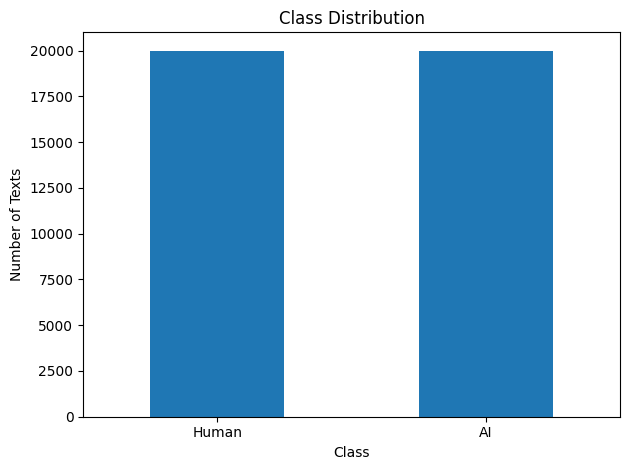

In [5]:
label_names = {0: "Human", 1: "AI"}

class_counts = df["label"].map(label_names).value_counts().reindex(["Human", "AI"])
ax = class_counts.plot(kind="bar")
ax.set_title("Class Distribution")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Texts")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

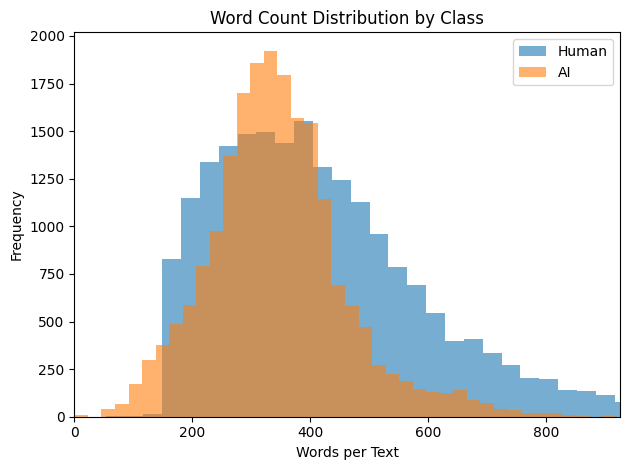

In [6]:
for label, name in label_names.items():
    subset = df.loc[df["label"] == label, "word_count"]
    plt.hist(subset, bins=50, alpha=0.6, label=name)

plt.title("Word Count Distribution by Class")
plt.xlabel("Words per Text")
plt.ylabel("Frequency")
plt.xlim(0, df["word_count"].quantile(0.99))
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
human_mean = df.loc[df["label"] == 0, "word_count"].mean()
ai_mean = df.loc[df["label"] == 1, "word_count"].mean()
human_median = df.loc[df["label"] == 0, "word_count"].median()
ai_median = df.loc[df["label"] == 1, "word_count"].median()

print(f"Human mean word count: {human_mean:.1f}")
print(f"AI mean word count: {ai_mean:.1f}")
print(f"Human median word count: {human_median:.0f}")
print(f"AI median word count: {ai_median:.0f}")
print(f"Mean difference: {human_mean - ai_mean:.1f} words")

Human mean word count: 422.1
AI mean word count: 344.1
Human median word count: 390
AI median word count: 336
Mean difference: 78.0 words


### Observed Length Pattern

The EDA showed a clear length difference between the two classes. Human-written texts contained an average of **422.1 words**, while AI-generated texts averaged **344.1 words**, a difference of about **78 words**. The median also followed the same pattern: **390 words for human texts** and **336 words for AI texts**.

This means text length could act as a shortcut in this dataset. A classifier might partially learn that longer texts are more likely to be human, even though length is not reliable proof of authorship. The later length-based error analysis supports checking this concern directly rather than assuming the detector learned only writing style.


## 4. Inspect Actual Human and AI Examples

In [8]:
for label, name in label_names.items():
    print(f"\n{name.upper()} EXAMPLES")
    print("=" * 100)
    examples = df[df["label"] == label].sample(2, random_state=SEED)
    for _, row in examples.iterrows():
        print(row["text"][:1000].replace("\n", " "))
        print("\n" + "-" * 100)


HUMAN EXAMPLES
Working with a group is more beneficial or working alone is more beneficial? Working with a group is more beneficial. People can get hell from another person, and they can be more successful by working together. Although some people thinks that working alone is more beneficial, working with a group is more successful because it would be easier to ask for hell and to succeed in life.  Some people thinks that working alone is more successful. It gives people time to plan and easier to make good efforts. Some people refers to not work with a group because they might make bad efforts on other people's work. Overall people says that working by yourself is more beneficial, they are wrong because working with a group can hell you be more successful.  Some people refers to work with a group. It is more helpful to get hell from another person. Some people had a hard time planning what they want to work on like homework or school project. Working with a group is more successful b

### Initial Qualitative Review

The examples should be examined for visible patterns such as sentence variation, repetition, personal voice, grammar, paragraph organization, formulaic transitions, and topic. These observations are only hypotheses until supported by model features or repeated error patterns.

## 5. Create a Reproducible 80/10/10 Split

In [9]:
train_df, temporary_df = train_test_split(
    df[["text", "label"]],
    test_size=0.20,
    stratify=df["label"],
    random_state=SEED
)

validation_df, test_df = train_test_split(
    temporary_df,
    test_size=0.50,
    stratify=temporary_df["label"],
    random_state=SEED
)

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test:", test_df.shape)

for split_name, split_df in {
    "Train": train_df,
    "Validation": validation_df,
    "Test": test_df
}.items():
    print(f"\n{split_name} distribution:")
    print(split_df["label"].value_counts().sort_index())

Train: (32000, 2)
Validation: (4000, 2)
Test: (4000, 2)

Train distribution:
label
0    16000
1    16000
Name: count, dtype: int64

Validation distribution:
label
0    2000
1    2000
Name: count, dtype: int64

Test distribution:
label
0    2000
1    2000
Name: count, dtype: int64


The split contains 32,000 training texts, 4,000 validation texts, and 4,000 test texts. Stratification preserves the 50/50 class balance. The same split is used for both models to support a fair comparison.

# Part A: Classic Baseline

## 6. TF-IDF Feature Extraction

In [10]:
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    max_features=50_000,
    sublinear_tf=True
)

X_train = tfidf_vectorizer.fit_transform(train_df["text"])
X_validation = tfidf_vectorizer.transform(validation_df["text"])
X_test = tfidf_vectorizer.transform(test_df["text"])

print("Train matrix:", X_train.shape)
print("Validation matrix:", X_validation.shape)
print("Test matrix:", X_test.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

Train matrix: (32000, 50000)
Validation matrix: (4000, 50000)
Test matrix: (4000, 50000)
Vocabulary size: 50000


Unigrams and bigrams capture individual terms and short phrases. Sublinear term frequency reduces the impact of repeated words. Features appearing in fewer than three documents are removed, and the vocabulary is capped at 50,000 features to control memory use.

## 7. Train Logistic Regression

In [11]:
baseline_model = LogisticRegression(
    max_iter=1000,
    solver="liblinear",
    random_state=SEED
)

baseline_model.fit(X_train, train_df["label"])

baseline_validation_predictions = baseline_model.predict(X_validation)
baseline_test_predictions = baseline_model.predict(X_test)
baseline_test_probabilities = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline training complete.")

Baseline training complete.


## 8. Baseline Metrics

In [12]:
def calculate_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0)
    }

baseline_validation_metrics = calculate_metrics(
    validation_df["label"], baseline_validation_predictions
)
baseline_test_metrics = calculate_metrics(
    test_df["label"], baseline_test_predictions
)

display(pd.DataFrame(
    [baseline_validation_metrics, baseline_test_metrics],
    index=["Validation", "Test"]
).round(4))

print(classification_report(
    test_df["label"],
    baseline_test_predictions,
    target_names=["Human", "AI"],
    digits=4
))

,accuracy,precision,recall,f1
Validation,0.9878,0.9904,0.985,0.9877
Test,0.9868,0.9934,0.980,0.9867


              precision    recall  f1-score   support

       Human     0.9803    0.9935    0.9868      2000
          AI     0.9934    0.9800    0.9867      2000

    accuracy                         0.9868      4000
   macro avg     0.9868    0.9868    0.9867      4000
weighted avg     0.9868    0.9868    0.9867      4000



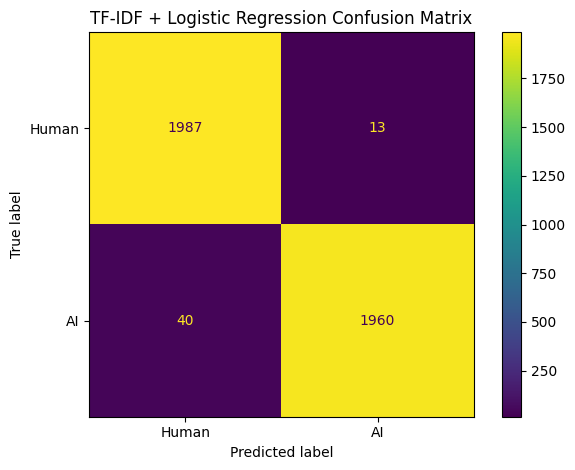

TN, FP, FN, TP: 1987 13 40 1960


In [13]:
baseline_cm = confusion_matrix(
    test_df["label"], baseline_test_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=baseline_cm,
    display_labels=["Human", "AI"]
).plot(values_format="d")

plt.title("TF-IDF + Logistic Regression Confusion Matrix")
plt.tight_layout()
plt.show()

tn_b, fp_b, fn_b, tp_b = baseline_cm.ravel()
print("TN, FP, FN, TP:", tn_b, fp_b, fn_b, tp_b)

In [14]:
print(
    f"The baseline achieved {baseline_test_metrics['accuracy']*100:.2f}% accuracy, "
    f"{baseline_test_metrics['precision']*100:.2f}% precision, "
    f"{baseline_test_metrics['recall']*100:.2f}% recall, and "
    f"{baseline_test_metrics['f1']*100:.2f}% F1 on the test set."
)

print(
    f"It correctly classified {tn_b} human texts and {tp_b} AI texts. "
    f"It produced {fp_b} false positives and {fn_b} false negatives."
)

if fn_b > fp_b:
    print(
        f"The model missed more AI texts than it falsely accused human texts. "
        f"False negatives were {fn_b/fp_b:.2f} times as common as false positives."
    )
else:
    print(
        "The model produced at least as many false positives as false negatives."
    )

The baseline achieved 98.67% accuracy, 99.34% precision, 98.00% recall, and 98.67% F1 on the test set.
It correctly classified 1987 human texts and 1960 AI texts. It produced 13 false positives and 40 false negatives.
The model missed more AI texts than it falsely accused human texts. False negatives were 3.08 times as common as false positives.


### Baseline Interpretation

The TF-IDF + Logistic Regression baseline achieved **98.67% accuracy**, **99.34% precision**, **98.00% recall**, and **98.67% F1-score** on the 4,000-text test set.

The confusion matrix showed **1,987 correctly classified human texts**, **1,960 correctly classified AI texts**, **13 false positives**, and **40 false negatives**. False negatives were therefore about **3.08 times more common** than false positives. This means the baseline was extremely cautious when assigning the AI label: when it predicted AI, it was usually correct, but it missed 40 generated texts.

The result is very strong for a classic model, but it also raises a concern about dataset shortcuts. The most influential AI-associated features included words such as **“important,” “additionally,” “potential,” “essay,” “conclusion,” “firstly,”** and **“essential.”** Human-associated features included **“people,” “going,” “car,” “students,” “percent,” “paragraph,”** and **“school.”** Some of these terms appear topic- or source-specific, suggesting that TF-IDF may be learning dataset construction patterns in addition to genuine stylistic differences.


## 9. Baseline Feature Interpretation

In [15]:
feature_names = np.array(tfidf_vectorizer.get_feature_names_out())
coefficients = baseline_model.coef_[0]

top_ai_indices = np.argsort(coefficients)[-25:][::-1]
top_human_indices = np.argsort(coefficients)[:25]

feature_table = pd.DataFrame({
    "AI-associated feature": feature_names[top_ai_indices],
    "AI coefficient": coefficients[top_ai_indices],
    "Human-associated feature": feature_names[top_human_indices],
    "Human coefficient": coefficients[top_human_indices]
})

display(feature_table)

,AI-associated feature,AI coefficient,Human-associated feature,Human coefficient
0,important,6.138779,people,-5.151128
1,additionally,4.882975,going,-4.878352
2,potential,4.769946,car,-4.558261
3,essay,4.743736,students,-4.484299
4,super,4.694860,student,-4.212097
5,hey,4.593774,percent,-4.183531
6,conclusion,4.229851,paragraph,-4.060819
7,provide,3.809436,venus,-4.058824
8,significant,3.307667,reason,-3.992976
9,lead,3.080738,driving,-3.972476


Positive coefficients push predictions toward AI, while negative coefficients push predictions toward human. These terms are correlations in this dataset, not universal evidence of authorship. Topic terms or formatting fragments may reveal how the dataset was assembled.

# Part B: Transformer Fine-Tuning

## 10. DistilBERT Configuration

DistilBERT is selected because it provides contextual representations with lower training cost than BERT-base. The notebook supports two modes:

- `FAST_MODE = True`: uses a smaller stratified training subset for quick testing.
- `FAST_MODE = False`: uses the complete 32,000-example training split for final results.

For the final submitted run, use `FAST_MODE = False` if GPU time permits.

In [16]:
FAST_MODE = False

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256

if FAST_MODE:
    transformer_train_df, _ = train_test_split(
        train_df,
        train_size=8000,
        stratify=train_df["label"],
        random_state=SEED
    )
else:
    transformer_train_df = train_df.copy()

print("Transformer training rows:", len(transformer_train_df))
print(transformer_train_df["label"].value_counts().sort_index())

Transformer training rows: 32000
label
0    16000
1    16000
Name: count, dtype: int64


## 11. Convert to Hugging Face Datasets and Tokenize

In [17]:
hf_dataset = DatasetDict({
    "train": Dataset.from_pandas(
        transformer_train_df.reset_index(drop=True),
        preserve_index=False
    ),
    "validation": Dataset.from_pandas(
        validation_df.reset_index(drop=True),
        preserve_index=False
    ),
    "test": Dataset.from_pandas(
        test_df.reset_index(drop=True),
        preserve_index=False
    )
})

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_dataset = hf_dataset.map(
    tokenize_batch,
    batched=True,
    desc="Tokenizing"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
print(tokenized_dataset)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing:   0%|          | 0/32000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4000 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/4000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 32000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
})


Dynamic padding is used so each batch is padded only to its longest text. The maximum length is 256 tokens to balance information retention and GPU memory. Longer texts are truncated, which is a limitation discussed later.

## 12. Metric Function

In [18]:
def transformer_compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return calculate_metrics(labels, predictions)

## 13. Controlled Hyperparameter Experiments

Two compact experiments are included to demonstrate systematic tuning. Both use the same data and evaluation metric. Validation F1 determines the best configuration.

The experiments differ in learning rate and batch size:

- Experiment A: learning rate 2e-5, batch size 8
- Experiment B: learning rate 3e-5, batch size 16

Both run for up to 2 epochs with early stopping.

In [19]:
experiment_configs = [
    {
        "name": "Experiment_A",
        "learning_rate": 2e-5,
        "train_batch_size": 8,
        "eval_batch_size": 16,
        "epochs": 2
    },
    {
        "name": "Experiment_B",
        "learning_rate": 3e-5,
        "train_batch_size": 16,
        "eval_batch_size": 32,
        "epochs": 2
    }
]

experiment_results = []
trained_experiments = {}

for config in experiment_configs:
    print("\n" + "=" * 100)
    print(config["name"], config)
    print("=" * 100)

    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2,
        id2label={0: "HUMAN", 1: "AI"},
        label2id={"HUMAN": 0, "AI": 1}
    )

    args_dict = dict(
        output_dir=f"./{config['name']}_checkpoints",
        num_train_epochs=config["epochs"],
        per_device_train_batch_size=config["train_batch_size"],
        per_device_eval_batch_size=config["eval_batch_size"],
        learning_rate=config["learning_rate"],
        weight_decay=0.01,
        logging_steps=100,
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        greater_is_better=True,
        report_to="none",
        seed=SEED,
        fp16=torch.cuda.is_available(),
        save_total_limit=1
    )

    signature = inspect.signature(TrainingArguments.__init__).parameters
    args_dict[
        "eval_strategy" if "eval_strategy" in signature else "evaluation_strategy"
    ] = "epoch"

    training_args = TrainingArguments(**args_dict)

    trainer_kwargs = dict(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],
        data_collator=data_collator,
        compute_metrics=transformer_compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=1)]
    )

    trainer_signature = inspect.signature(Trainer.__init__).parameters
    if "processing_class" in trainer_signature:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer

    trainer = Trainer(**trainer_kwargs)
    trainer.train()
    validation_result = trainer.evaluate(tokenized_dataset["validation"])

    result_row = {
        "experiment": config["name"],
        "learning_rate": config["learning_rate"],
        "train_batch_size": config["train_batch_size"],
        "epochs": config["epochs"],
        "validation_accuracy": validation_result["eval_accuracy"],
        "validation_precision": validation_result["eval_precision"],
        "validation_recall": validation_result["eval_recall"],
        "validation_f1": validation_result["eval_f1"],
        "validation_loss": validation_result["eval_loss"]
    }

    experiment_results.append(result_row)
    trained_experiments[config["name"]] = trainer

experiment_results_df = pd.DataFrame(experiment_results)
display(experiment_results_df.sort_values("validation_f1", ascending=False))


Experiment_A {'name': 'Experiment_A', 'learning_rate': 2e-05, 'train_batch_size': 8, 'eval_batch_size': 16, 'epochs': 2}


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.044232,0.027399,0.992500,0.988107,0.997000,0.992534
2,0.010436,0.026840,0.994000,0.989109,0.999000,0.994030


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.010436,0.026840,2,0.994000,0.989109,0.999000,0.994030


,experiment,learning_rate,train_batch_size,epochs,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_loss
0,Experiment_A,0.00002,8,2,0.99575,0.994021,0.9975,0.995757,0.022021
1,Experiment_B,0.00003,16,2,0.99400,0.989109,0.9990,0.994030,0.026840


## 14. Select the Best DistilBERT Configuration

In [20]:
best_experiment_name = (
    experiment_results_df
    .sort_values("validation_f1", ascending=False)
    .iloc[0]["experiment"]
)

best_trainer = trained_experiments[best_experiment_name]

print("Best experiment:", best_experiment_name)
display(
    experiment_results_df[
        experiment_results_df["experiment"] == best_experiment_name
    ]
)

Best experiment: Experiment_A


,experiment,learning_rate,train_batch_size,epochs,validation_accuracy,validation_precision,validation_recall,validation_f1,validation_loss
0,Experiment_A,0.00002,8,2,0.99575,0.994021,0.9975,0.995757,0.022021


The best configuration is selected using validation F1 only. The test set is not used for hyperparameter selection, reducing the risk of overfitting conclusions to the final evaluation data.

## 15. Final DistilBERT Test Evaluation

In [21]:
transformer_test_output = best_trainer.predict(tokenized_dataset["test"])

transformer_test_logits = transformer_test_output.predictions
transformer_test_predictions = np.argmax(transformer_test_logits, axis=-1)
transformer_test_probabilities = torch.softmax(
    torch.tensor(transformer_test_logits),
    dim=1
).numpy()[:, 1]

transformer_test_metrics = calculate_metrics(
    test_df["label"].to_numpy(),
    transformer_test_predictions
)

print("DistilBERT test metrics:")
for name, value in transformer_test_metrics.items():
    print(f"{name}: {value:.4f} ({value*100:.2f}%)")

print("\nClassification report:")
print(classification_report(
    test_df["label"],
    transformer_test_predictions,
    target_names=["Human", "AI"],
    digits=4
))

DistilBERT test metrics:
accuracy: 0.9930 (99.30%)
precision: 0.9920 (99.20%)
recall: 0.9940 (99.40%)
f1: 0.9930 (99.30%)

Classification report:
              precision    recall  f1-score   support

       Human     0.9940    0.9920    0.9930      2000
          AI     0.9920    0.9940    0.9930      2000

    accuracy                         0.9930      4000
   macro avg     0.9930    0.9930    0.9930      4000
weighted avg     0.9930    0.9930    0.9930      4000



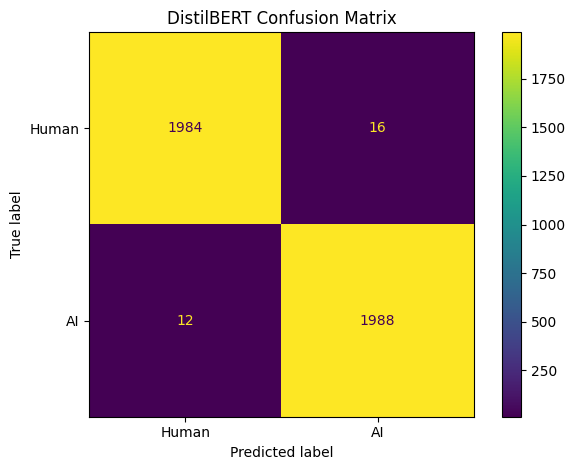

TN, FP, FN, TP: 1984 16 12 1988


In [22]:
transformer_cm = confusion_matrix(
    test_df["label"],
    transformer_test_predictions
)

ConfusionMatrixDisplay(
    confusion_matrix=transformer_cm,
    display_labels=["Human", "AI"]
).plot(values_format="d")

plt.title("DistilBERT Confusion Matrix")
plt.tight_layout()
plt.show()

tn_t, fp_t, fn_t, tp_t = transformer_cm.ravel()
print("TN, FP, FN, TP:", tn_t, fp_t, fn_t, tp_t)

In [23]:
print(
    f"DistilBERT achieved {transformer_test_metrics['accuracy']*100:.2f}% accuracy, "
    f"{transformer_test_metrics['precision']*100:.2f}% precision, "
    f"{transformer_test_metrics['recall']*100:.2f}% recall, and "
    f"{transformer_test_metrics['f1']*100:.2f}% F1."
)

print(
    f"It correctly classified {tn_t} human texts and {tp_t} AI texts. "
    f"It produced {fp_t} false positives and {fn_t} false negatives."
)

DistilBERT achieved 99.30% accuracy, 99.20% precision, 99.40% recall, and 99.30% F1.
It correctly classified 1984 human texts and 1988 AI texts. It produced 16 false positives and 12 false negatives.


# Part C: Direct Model Comparison

## 16. Compare All Required Metrics

In [24]:
comparison_df = pd.DataFrame({
    "TF-IDF + Logistic Regression": baseline_test_metrics,
    "DistilBERT": transformer_test_metrics
}).T

comparison_df["false_positives"] = [fp_b, fp_t]
comparison_df["false_negatives"] = [fn_b, fn_t]

display(comparison_df.round(4))

,accuracy,precision,recall,f1,false_positives,false_negatives
TF-IDF + Logistic Regression,0.9868,0.9934,0.980,0.9867,13,40
DistilBERT,0.9930,0.9920,0.994,0.9930,16,12


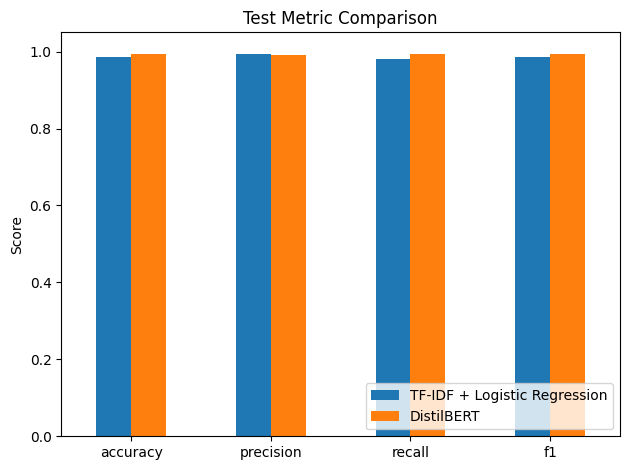

In [25]:
metric_names = ["accuracy", "precision", "recall", "f1"]

comparison_df[metric_names].T.plot(kind="bar")
plt.title("Test Metric Comparison")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [26]:
metric_differences = {
    metric: transformer_test_metrics[metric] - baseline_test_metrics[metric]
    for metric in ["accuracy", "precision", "recall", "f1"]
}

print("DistilBERT minus baseline:")
for metric, difference in metric_differences.items():
    print(f"{metric}: {difference:+.4f} ({difference*100:+.2f} percentage points)")

if metric_differences["f1"] > 0:
    print(
        f"DistilBERT outperformed the baseline in F1 by "
        f"{metric_differences['f1']*100:.2f} percentage points."
    )
else:
    print(
        f"The classic baseline outperformed DistilBERT in F1 by "
        f"{abs(metric_differences['f1'])*100:.2f} percentage points."
    )

print(
    f"False positives changed from {fp_b} to {fp_t}, "
    f"and false negatives changed from {fn_b} to {fn_t}."
)

DistilBERT minus baseline:
accuracy: +0.0062 (+0.62 percentage points)
precision: -0.0014 (-0.14 percentage points)
recall: +0.0140 (+1.40 percentage points)
f1: +0.0063 (+0.63 percentage points)
DistilBERT outperformed the baseline in F1 by 0.63 percentage points.
False positives changed from 13 to 16, and false negatives changed from 40 to 12.


### Comparison Interpretation

DistilBERT achieved **99.30% accuracy** and **99.30% F1-score**, compared with **98.67% accuracy** and **98.67% F1-score** for TF-IDF + Logistic Regression. The Transformer therefore improved accuracy by **0.62 percentage points** and F1 by **0.63 percentage points**.

The largest improvement was in AI recall, which increased from **98.00% to 99.40%**, a gain of **1.40 percentage points**. DistilBERT reduced false negatives from **40 to 12**, meaning it detected 28 additional AI-generated texts that the baseline missed.

However, AI precision decreased slightly from **99.34% to 99.20%**, and false positives increased from **13 to 16**. Therefore, DistilBERT was better overall and much better at finding generated text, but it produced three additional false accusations of human writing. This trade-off matters because a small gain in overall performance does not remove the ethical importance of false positives.


# Part D: Detailed Error Analysis

## 17. Build Error Tables for Both Models

In [27]:
test_results = test_df.reset_index(drop=True).copy()

test_results["baseline_prediction"] = baseline_test_predictions
test_results["baseline_ai_probability"] = baseline_test_probabilities
test_results["transformer_prediction"] = transformer_test_predictions
test_results["transformer_ai_probability"] = transformer_test_probabilities
test_results["word_count"] = test_results["text"].str.split().str.len()

def assign_error_type(true_label, predicted_label):
    if true_label == predicted_label:
        return "Correct"
    if true_label == 0 and predicted_label == 1:
        return "False Positive"
    return "False Negative"

test_results["baseline_error_type"] = [
    assign_error_type(y, p)
    for y, p in zip(
        test_results["label"],
        test_results["baseline_prediction"]
    )
]

test_results["transformer_error_type"] = [
    assign_error_type(y, p)
    for y, p in zip(
        test_results["label"],
        test_results["transformer_prediction"]
    )
]

test_results.to_csv("final_model_predictions_and_errors.csv", index=False)

print("Baseline errors:")
print(test_results["baseline_error_type"].value_counts())

print("\nTransformer errors:")
print(test_results["transformer_error_type"].value_counts())

Baseline errors:
baseline_error_type
Correct           3947
False Negative      40
False Positive      13
Name: count, dtype: int64

Transformer errors:
transformer_error_type
Correct           3972
False Positive      16
False Negative      12
Name: count, dtype: int64


## 18. Inspect Specific False Positives and False Negatives

In [28]:
def show_errors(
    results_df,
    error_column,
    probability_column,
    error_type,
    n=3
):
    subset = results_df[results_df[error_column] == error_type].copy()

    if error_type == "False Positive":
        subset = subset.sort_values(probability_column, ascending=False)
    else:
        subset = subset.sort_values(probability_column, ascending=True)

    print(f"\n{error_type.upper()} EXAMPLES")
    print("=" * 100)

    for _, row in subset.head(n).iterrows():
        print("True label:", label_names[row["label"]])
        print("Word count:", row["word_count"])
        print("AI probability:", round(row[probability_column], 4))
        print(row["text"][:1400].replace("\n", " "))
        print("\n" + "-" * 100)

print("BASELINE")
show_errors(
    test_results,
    "baseline_error_type",
    "baseline_ai_probability",
    "False Positive"
)
show_errors(
    test_results,
    "baseline_error_type",
    "baseline_ai_probability",
    "False Negative"
)

print("\nDISTILBERT")
show_errors(
    test_results,
    "transformer_error_type",
    "transformer_ai_probability",
    "False Positive"
)
show_errors(
    test_results,
    "transformer_error_type",
    "transformer_ai_probability",
    "False Negative"
)

BASELINE

FALSE POSITIVE EXAMPLES
True label: Human
Word count: 195
AI probability: 0.8774
Can a positive attitude be the key to success in life, or should we live the way we believe is better?  Daily we live the way we want to. But, sometimes we don't consider the important things that can make us success in life. Attitude can be one of those facts that can make us success. Their are some specific reasons about the importance of attitude and why we should consider this or not a fact to success in life.  The importance of attitude is a fact to success in life. As we know, we need a positive attitude to get some things in life. For example, in a job to get better opportunities we need a positive attitude to develop our skills.  EO live a healthy life. For example, if we have a positive attitude we will avoid dangerous sickness.  Easier way to live. For example, being relaxed is a result of having a positive attitude.  In conclusion, a positive attitude is the key of success. It teaches 

### Analysis of the Actual Misclassified Examples

The baseline’s most confident false positive had an AI probability of **0.8774**. It was a 195-word human essay about positive attitude. The text used a formulaic structure, repeated phrases such as *“positive attitude”*, included several explicit examples, and ended with *“In conclusion.”* These features resemble the baseline’s strongest AI-associated TF-IDF terms and likely pushed the prediction toward AI, even though the text contained visible human grammar errors such as *“make us success”* and *“Their are.”*

Two other highly confident baseline false positives were human essays about distance learning. They were long, organized into clear argumentative paragraphs, and used formal transitions. Their similarity to structured essay templates likely outweighed signs of human writing.

The baseline’s false negatives included AI-generated texts containing many spelling and grammatical errors, such as *“I thing,” “lite tutoring,” “loots good Food collage,”* and *“mates them feel good.”* Because the human class contained student writing with similar errors, the lexical model treated these generated examples as human. This shows that an AI system can evade a detector by imitating noisy student writing.

DistilBERT’s most confident false positives included a 537-word human essay assigned an AI probability of **0.9997**. Although it contained grammar errors, it followed a repeated, highly organized argumentative pattern with phrases such as *“One of the main reasons”* and *“Another reason.”* The model appears to have treated its consistent structure as stronger evidence than the errors.

DistilBERT’s most confident false negatives were AI texts with deliberately corrupted or student-like language. One 415-word example used repeated grammatical errors and placeholder names such as **“Generic_Name.”** Another repeatedly replaced *school* with *“stool”* and used forms such as *“Lometimes”* and *“I tank.”* A third contained systematic character substitutions such as *“IJ,” “it'j,”* and *“haj.”* These examples show that generated text can be made to resemble low-quality human writing closely enough to fool even a contextual Transformer.


## 19. Compare Shared and Model-Specific Mistakes

In [29]:
baseline_wrong = test_results["baseline_error_type"] != "Correct"
transformer_wrong = test_results["transformer_error_type"] != "Correct"

shared_errors = test_results[baseline_wrong & transformer_wrong]
baseline_only_errors = test_results[baseline_wrong & ~transformer_wrong]
transformer_only_errors = test_results[~baseline_wrong & transformer_wrong]

print("Errors made by both models:", len(shared_errors))
print("Errors made only by baseline:", len(baseline_only_errors))
print("Errors made only by DistilBERT:", len(transformer_only_errors))

Errors made by both models: 12
Errors made only by baseline: 41
Errors made only by DistilBERT: 16


In [30]:
print(
    f"Both models failed on {len(shared_errors)} of the same texts. "
    f"DistilBERT corrected {len(baseline_only_errors)} baseline mistakes, "
    f"while introducing {len(transformer_only_errors)} mistakes on texts "
    f"the baseline classified correctly."
)

Both models failed on 12 of the same texts. DistilBERT corrected 41 baseline mistakes, while introducing 16 mistakes on texts the baseline classified correctly.


Shared errors may indicate genuinely ambiguous texts or dataset-label problems. Model-specific errors reveal differences between lexical TF-IDF features and contextual Transformer representations.

## 20. Error Rate by Text Length

In [31]:
test_results["length_group"] = pd.qcut(
    test_results["word_count"],
    q=4,
    labels=["Shortest", "Short-Medium", "Long-Medium", "Longest"]
)

length_error_table = test_results.groupby("length_group", observed=False).apply(
    lambda group: pd.Series({
        "count": len(group),
        "baseline_error_rate": (
            group["baseline_error_type"] != "Correct"
        ).mean(),
        "transformer_error_rate": (
            group["transformer_error_type"] != "Correct"
        ).mean()
    })
)

display(length_error_table.round(4))

,count,baseline_error_rate,transformer_error_rate
length_group,,,
Shortest,1002.0,0.0190,0.0070
Short-Medium,1007.0,0.0109,0.0040
Long-Medium,991.0,0.0151,0.0081
Longest,1000.0,0.0080,0.0090


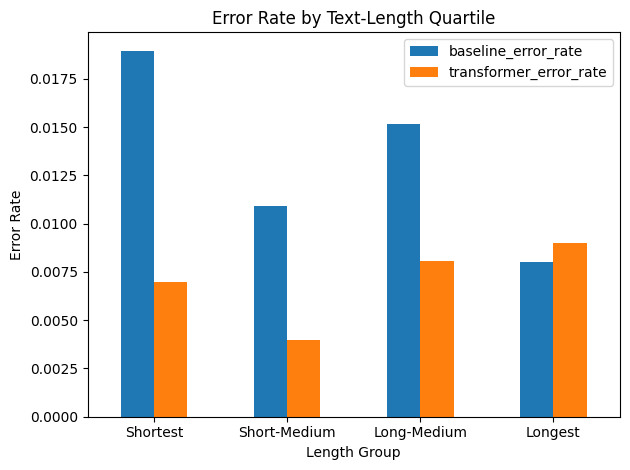

In [32]:
length_error_table[
    ["baseline_error_rate", "transformer_error_rate"]
].plot(kind="bar")

plt.title("Error Rate by Text-Length Quartile")
plt.ylabel("Error Rate")
plt.xlabel("Length Group")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
baseline_worst_length = length_error_table["baseline_error_rate"].idxmax()
transformer_worst_length = length_error_table["transformer_error_rate"].idxmax()

print(
    f"The baseline's highest error rate occurred in the "
    f"{baseline_worst_length} text group."
)
print(
    f"DistilBERT's highest error rate occurred in the "
    f"{transformer_worst_length} text group."
)

The baseline's highest error rate occurred in the Shortest text group.
DistilBERT's highest error rate occurred in the Longest text group.


# Part E: Ethical Considerations

## 21. Ethics Tied to the Observed Results

The most serious deployment risk is a false positive, where a human-written text is classified as AI-generated. The baseline produced **13 false positives**, while DistilBERT produced **16**. Although these numbers are small relative to 2,000 human test texts, each mistake represents a person who could be wrongly accused.

The actual false positives show why automatic punishment would be unsafe. Several human essays were flagged because they used clear organization, repeated transitions, and formulaic conclusions. These are common features of classroom writing, especially when students follow taught essay structures. One human essay received an AI probability of **0.9997**, demonstrating that even very high model confidence does not guarantee correctness.

This risk may disproportionately affect non-native English writers. Some false-positive human texts combined structured academic organization with grammar errors. A detector may interpret learned templates, repeated phrasing, or translation-influenced language as signs of AI generation.

False negatives also demonstrate that the tool is not reliable proof of human authorship. The baseline missed **40 AI texts**, and DistilBERT missed **12**. Several missed AI examples intentionally included spelling errors, awkward grammar, placeholder names, and corrupted words. This suggests that generated text can evade detection by imitating student mistakes or by being edited after generation.

The model comparison also reveals an ethical trade-off. DistilBERT reduced false negatives from 40 to 12, but increased false positives from 13 to 16. It is therefore better at detecting AI text overall, but slightly more likely to accuse a human writer incorrectly.

For these reasons, the detector should only be used as a screening tool. A prediction should trigger further human review, not automatic penalties. Reviewers should examine writing history, drafts, citations, assignment context, and opportunities for the student to explain their process. The measured errors in this project show that model confidence must never be treated as conclusive evidence.


## 22. Limitations

1. The dataset is a balanced sample, while real-world class proportions may be different.
2. The results may depend on dataset-specific topics, formatting, or source artifacts.
3. DistilBERT truncates texts beyond 256 tokens.
4. Only one Transformer architecture is evaluated.
5. Performance against newer models, paraphrased AI text, and heavily edited text is unknown.
6. Hyperparameter tuning is intentionally limited by course-project compute constraints.
7. High test performance does not prove that the detector will generalize to another institution or writing domain.

# Part F: Save Final Artifacts

In [34]:
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(baseline_model, "logistic_regression_baseline.joblib")

best_trainer.save_model("best_distilbert_ai_detector")
tokenizer.save_pretrained("best_distilbert_ai_detector")

comparison_df.to_csv("final_model_comparison.csv")
experiment_results_df.to_csv("distilbert_experiment_log.csv", index=False)
test_results.to_csv("final_model_predictions_and_errors.csv", index=False)

train_df.to_csv("train_split.csv", index=False)
validation_df.to_csv("validation_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

print("All final artifacts saved.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

All final artifacts saved.


# Final Conclusion

The TF-IDF + Logistic Regression baseline achieved **98.67% F1**, while DistilBERT achieved **99.30% F1**. DistilBERT was the stronger overall model, improving F1 by **0.63 percentage points** and reducing false negatives from **40 to 12**.

The improvement was not uniform across every metric. DistilBERT’s AI recall increased from **98.00% to 99.40%**, but its precision decreased slightly from **99.34% to 99.20%**. It also increased false positives from **13 to 16**. Therefore, the Transformer detected more generated text but made slightly more incorrect accusations of human writing.

The two models shared **12 errors**. DistilBERT corrected **41 baseline mistakes**, but introduced **16 new mistakes** on texts that Logistic Regression classified correctly. Length analysis also showed different weaknesses: the baseline had its highest error rate in the **shortest** text quartile, while DistilBERT had its highest error rate in the **longest** quartile. This may partly reflect the Transformer’s 256-token truncation limit.

The specific errors showed that formal structure and repeated transitions can cause human writing to be flagged, while generated texts containing deliberate spelling mistakes and awkward grammar can appear human. These results demonstrate that high accuracy does not make an AI-text detector definitive. The system is suitable only as a support tool for further review, not as standalone proof of misconduct.


In [35]:
best_model_name = (
    "DistilBERT"
    if transformer_test_metrics["f1"] > baseline_test_metrics["f1"]
    else "TF-IDF + Logistic Regression"
)

print(
    f"The classic baseline achieved {baseline_test_metrics['f1']*100:.2f}% F1, "
    f"while DistilBERT achieved {transformer_test_metrics['f1']*100:.2f}% F1."
)

print(
    f"Based on test F1, the stronger model was {best_model_name}. "
    f"However, the final judgment should also consider false positives, "
    f"false negatives, computation cost, interpretability, and deployment risk."
)

print(
    f"The baseline produced {fp_b} false positives and {fn_b} false negatives. "
    f"DistilBERT produced {fp_t} false positives and {fn_t} false negatives."
)

The classic baseline achieved 98.67% F1, while DistilBERT achieved 99.30% F1.
Based on test F1, the stronger model was DistilBERT. However, the final judgment should also consider false positives, false negatives, computation cost, interpretability, and deployment risk.
The baseline produced 13 false positives and 40 false negatives. DistilBERT produced 16 false positives and 12 false negatives.


This project shows that both classic and Transformer-based methods can perform strongly on AI-generated text detection. The classic baseline is fast and interpretable, while DistilBERT uses contextual representations and may correct some lexical-model mistakes. Nevertheless, neither model should be treated as definitive proof of authorship. The observed false positives, false negatives, and potential dataset shortcuts support the use of human review and cautious interpretation.